<a href="https://colab.research.google.com/github/bello1987/muhammed/blob/main/data_interactivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Click on the badge, then `Copy to Drive` before continuing.

Muhammed Bello

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/allegheny-college-cmpsc-105-spring-2026/data-interactivity-starter/blob/main/data_interactivity.ipynb)

# Data Interactivity Lab

---

In this lab, you will explore [World Happiness Data](https://zenodo.org/records/14826965). The World Happiness Report Team annually collects data from individuals around the world about their level of happiness and other judgements they make about their life. The team analyzes those data and produces reports that relate happiness ratings to other life factors. See their work for further details (https://worldhappiness.report/)

What is in this CMPSC 105 lab has already been de-identified and aggregated by country of residence. While this is not the raw data, there are still many mysteries contained within.

Your job is to make interactive displays that facilitate data exploration and lead to insights through visual comparisons.

In this lab, you have access to happiness data for approximately 155 locations over 5 years, 2015-2019. For each location and each year, there are several additional variables such as the Happiness Rank, Happiness Score, GDP per capita, Average social support, Average healthy life expectancy, Average freedom to make life choices, Average generosity level, and Average perceptions of corruption.

The variables for the five years likely have similar definitions to those quoted below from https://worldhappiness.report/ed/2023/world-happiness-trust-and-social-connections-in-times-of-crisis/:


>GDP per capita is in terms of Purchasing Power Parity (PPP) adjusted to constant 2017 international dollars, taken from the World Development Indicators (WDI) by the World Bank (version 17, metadata last updated on January 22, 2023). See Statistical Appendix 1 for more details. GDP data for 2022 are not yet available, so we extend the GDP time series from 2021 to 2022 using country-specific forecasts of real GDP growth from the OECD Economic Outlook No. 112 (November 2022) or, if missing, from the World Bank’s Global Economic Prospects (last updated: January 10, 2023), after adjustment for population growth. The equation uses the natural log of GDP per capita, as this form fits the data significantly better than GDP per capita.

>The time series for healthy life expectancy at birth are constructed based on data from the World Health Organization (WHO) Global Health Observatory data repository, with data available for 2005, 2010, 2015, 2016, and 2019. To match this report’s sample period (2005-2022), interpolation and extrapolation are used. See Statistical Appendix 1 for more details.

>Social support is the national average of the binary responses (0=no, 1=yes) to the Gallup World Poll (GWP) question “If you were in trouble, do you have relatives or friends you can count on to help you whenever you need them, or not?”

>Freedom to make life choices is the national average of binary responses to the GWP question “Are you satisfied or dissatisfied with your freedom to choose what you do with your life?”

>Generosity is the residual of regressing the national average of GWP responses to the donation question “Have you donated money to a charity in the past month?” on log GDP per capita.

>Perceptions of corruption are the average of binary answers to two GWP questions: “Is corruption widespread throughout the government or not?” and “Is corruption widespread within businesses or not?” Where data for government corruption are missing, the perception of business corruption is used as the overall corruption-perception measure.

Code is provided to load in the dataset into a Pandas dataframe called `dfwh`. The column names for the dataframe are `Country,Happiness Rank,Happiness Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year`. The raw data can be viewed here:

- https://raw.githubusercontent.com/allegheny-college-cmpsc-105-spring-2025/data-interactivity-starter/refs/heads/main/data/world-happiness-2015-2019-zenodo-14826965.csv

## Goals

Your goal is to use data filtering and interactivity techniques to isolate specific parts of the data, and then make visual comparisons

1. As a warm-up, explore the precoded figure.
2. Then do the follow-up explorations to gain additional understanding of the relationships between the GDP and happiness using two chart types.

Don't forget to answer all `T O D O` markers and to remove the markers.

## Deadline

This lab should be completed during the lab meeting time, but modifations may be made until the official deadline of 2:30pm on Feb 20th.

## Learning Outcomes

By completing this lab you will

- explore a dataset with interactive filtering
- write a report in a markdown cell
- update a GitHub Repository
- check gatorgrade in GitHub Actions

## Reminders

- If needed, one of four available automatic extension tokens can be applied by using the form on found on the course syllabus.
- If you have a question, post in the 105 Discord channel.
- Refer to previous materials to learn how to use Notebooks in Google Colab, make your work accessible, submit, and check your work.

## Saving Your Work

Saving your work and making it accessible is a required part of all labs.

### Accessability Part 1

Update the Colab file name to be `data_interactivity.ipynb`.

Make sure that all cells have been executed and are SHOWING their outputs.

### Saving

I would recommend a workflow of `Copy to Drive --> editing/running/testing --> downloading`. You should have already hit `Copy to Drive`, but if you haven't, then please do so now. Then go ahead and download the file from the menu at the top of the Colab interface. File > Download > Download ipynb

### Accessibility Part 2

If you are satisfied with your work, you can now upload the downloaded file to your GitHub repo!

- Use GitHub to upload the file.
  - Next to the green code button in GitHub, you will see an `add file` button. Click that, then choose the downloaded notebook from your computer.

## Checking Your Work

### Check your file output

Once your file is uploaded, please open it on GitHub. All the outputs and plots should be showing. If they are not showing, this means that not all code cells were executed before you downloaded your file.

### Check GitHub Actions

In GitHub, go to the Actions tab. Click on the top Action to see a report about your T O D Os. If the T O D Os have been done and deleted, then the actions will show that gatorgrade reports 100%. This is not your grade, but it is a good indication that you did not forget to do something.

If you see remaining T O D Os, then you may want to edit and update your file.

## Warmup

In [1]:
# This code cell makes pre-existing tools available for data exploration

import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact # pre existing code for interaction

In [2]:
# Run this code cell that creates a pandas dataframe for Meadville

dfwh = pd.read_csv(
    'https://raw.githubusercontent.com/allegheny-college-cmpsc-105-spring-2026/data-interactivity-starter/main/data/world-happiness-2015-2019-zenodo-14826965.csv',
    sep=',',
    names = ['Country',
             'Happiness Rank',
             'Happiness Score',
             'GDP per capita',
             'Social support',
             'Healthy life expectancy',
             'Freedom to make life choices',
             'Generosity',
             'Perceptions of corruption',
             'Year'],
    skiprows=1
)

print(dfwh.head()) # Display the first few rows of the DataFrame

       Country  Happiness Rank  Happiness Score  GDP per capita  \
0  Switzerland               1            7.587         1.39651   
1      Iceland               2            7.561         1.30232   
2      Denmark               3            7.527         1.32548   
3       Norway               4            7.522         1.45900   
4       Canada               5            7.427         1.32629   

   Social support  Healthy life expectancy  Freedom to make life choices  \
0         1.34951                  0.94143                       0.66557   
1         1.40223                  0.94784                       0.62877   
2         1.36058                  0.87464                       0.64938   
3         1.33095                  0.88521                       0.66973   
4         1.32261                  0.90563                       0.63297   

   Generosity  Perceptions of corruption  Year  
0     0.29678                    0.41978  2015  
1     0.43630                    0.14145  

In [3]:
### Please answer these questions before continuing.

# How many rows of data are there for dfwh (HINT: The answer is not 5) there are 782 rows of dfwh.
# : How many columns of data are there for dfwh? There are 10 columns in the dfwh dataset. Each column represents a different variable measured for each observation.
#  What is the range of the GDP column? The range of the GDP column is 1.563.
# : According to the definition given above, what transformation has been done to GDP? The GDP variable has been log-transformed (likely using the natural logarithm). This reduces large GDP values to a smaller scale and helps make the data less skewed and easier to analyze.

       Country  Happiness Rank  Happiness Score  GDP per capita  \
0  Switzerland               1            7.587         1.39651   
1      Iceland               2            7.561         1.30232   
2      Denmark               3            7.527         1.32548   
3       Norway               4            7.522         1.45900   
4       Canada               5            7.427         1.32629   

   Social support  Healthy life expectancy  Freedom to make life choices  \
0         1.34951                  0.94143                       0.66557   
1         1.40223                  0.94784                       0.62877   
2         1.36058                  0.87464                       0.64938   
3         1.33095                  0.88521                       0.66973   
4         1.32261                  0.90563                       0.63297   

   Generosity  Perceptions of corruption  Year  
0     0.29678                    0.41978  2015  
1     0.43630                    0.14145  

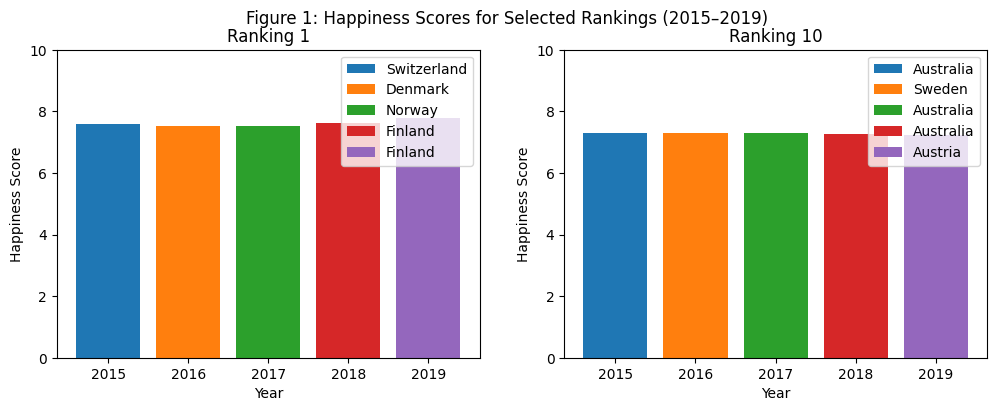

In [4]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
dfwh = pd.read_csv(
    'https://raw.githubusercontent.com/allegheny-college-cmpsc-105-spring-2026/data-interactivity-starter/main/data/world-happiness-2015-2019-zenodo-14826965.csv',
    sep=',',
    names = ['Country',
             'Happiness Rank',
             'Happiness Score',
             'GDP per capita',
             'Social support',
             'Healthy life expectancy',
             'Freedom to make life choices',
             'Generosity',
             'Perceptions of corruption',
             'Year'],
    skiprows=1
)

# Optional: check first few rows
print(dfwh.head())

# Clear memory (not required but keeps Colab happy)
plt.close('all')

# Masks for years
mask_2015 = dfwh['Year'] == 2015
mask_2016 = dfwh['Year'] == 2016
mask_2017 = dfwh['Year'] == 2017
mask_2018 = dfwh['Year'] == 2018
mask_2019 = dfwh['Year'] == 2019

# Plotting function
def plot_happiness_rank(hrank1, hrank2):

    mask_hrank1 = dfwh['Happiness Rank'] == hrank1
    mask_hrank2 = dfwh['Happiness Rank'] == hrank2

    # Blank canvas
    plt.figure(figsize=(12, 4))

    # Suptitle
    plt.suptitle('Figure 1: Happiness Scores for Selected Rankings (2015–2019)')

    # Subplot 1
    plt.subplot(1,2,1)
    plt.title(f'Ranking {hrank1}')
    plt.bar(dfwh.loc[mask_hrank1 & mask_2015,'Year'],
            dfwh.loc[mask_hrank1 & mask_2015,'Happiness Score'],
            label=dfwh.loc[mask_hrank1 & mask_2015,'Country'])
    plt.bar(dfwh.loc[mask_hrank1 & mask_2016,'Year'],
            dfwh.loc[mask_hrank1 & mask_2016,'Happiness Score'],
            label=dfwh.loc[mask_hrank1 & mask_2016,'Country'])
    plt.bar(dfwh.loc[mask_hrank1 & mask_2017,'Year'],
            dfwh.loc[mask_hrank1 & mask_2017,'Happiness Score'],
            label=dfwh.loc[mask_hrank1 & mask_2017,'Country'])
    plt.bar(dfwh.loc[mask_hrank1 & mask_2018,'Year'],
            dfwh.loc[mask_hrank1 & mask_2018,'Happiness Score'],
            label=dfwh.loc[mask_hrank1 & mask_2018,'Country'])
    plt.bar(dfwh.loc[mask_hrank1 & mask_2019,'Year'],
            dfwh.loc[mask_hrank1 & mask_2019,'Happiness Score'],
            label=dfwh.loc[mask_hrank1 & mask_2019,'Country'])
    plt.legend()
    plt.xlabel('Year')
    plt.ylabel('Happiness Score')
    plt.ylim(0, 10)

    # Subplot 2
    plt.subplot(1,2,2)
    plt.title(f'Ranking {hrank2}')
    plt.bar(dfwh.loc[mask_hrank2 & mask_2015,'Year'],
            dfwh.loc[mask_hrank2 & mask_2015,'Happiness Score'],
            label=dfwh.loc[mask_hrank2 & mask_2015,'Country'])
    plt.bar(dfwh.loc[mask_hrank2 & mask_2016,'Year'],
            dfwh.loc[mask_hrank2 & mask_2016,'Happiness Score'],
            label=dfwh.loc[mask_hrank2 & mask_2016,'Country'])
    plt.bar(dfwh.loc[mask_hrank2 & mask_2017,'Year'],
            dfwh.loc[mask_hrank2 & mask_2017,'Happiness Score'],
            label=dfwh.loc[mask_hrank2 & mask_2017,'Country'])
    plt.bar(dfwh.loc[mask_hrank2 & mask_2018,'Year'],
            dfwh.loc[mask_hrank2 & mask_2018,'Happiness Score'],
            label=dfwh.loc[mask_hrank2 & mask_2018,'Country'])
    plt.bar(dfwh.loc[mask_hrank2 & mask_2019,'Year'],
            dfwh.loc[mask_hrank2 & mask_2019,'Happiness Score'],
            label=dfwh.loc[mask_hrank2 & mask_2019,'Country'])
    plt.legend()
    plt.xlabel('Year')
    plt.ylabel('Happiness Score')
    plt.ylim(0, 10)

    # Show the figure
    plt.show()

# Call the function to generate the plot
plot_happiness_rank(1, 10)

In [5]:
# This code sets up ranges over which hrank1 and hrank2 are adjustable!
#  Run this cell

interact(plot_happiness_rank, hrank1=(1,156,1), hrank2=(1,156,1))

interactive(children=(IntSlider(value=78, description='hrank1', max=156, min=1), IntSlider(value=78, descripti…

<function __main__.plot_happiness_rank(hrank1, hrank2)>

In [6]:
### Please answer these questions before continuing.

# Based on the code above:
#  What column does mask_2015 base the comparison on and why? mask_2015 uses the Year column to select all rows from 2015 for plotting.
# : What column does mask_2016 base the comparison on and why?  The same logic mask_2016 uses the Year column to select all rows from 2016 for plotting.
#  Why could those masks not reference a different column? Because the x-axis is Year, the masks must filter on the Year column; using a different column would misalign the data with the years.
#  What is the difference in code between subplot 1 and subplot 2? subplot 1 uses hrank1 and mask_hrank1 while subplot 2 uses hranks 2 and mask_hrank 2,Everything else is basically the same, just plotting the second chosen rank.
#  What visually happens if you remove the y axis limits in the code from both subplots? The y-axis would rescale automatically, which can make differences between countries less visible and harder to compare across subplots.
#  The data are still accurate, but explain why the figure is less impactful? The figure is less impactful because the changing y-axis scale can exaggerate or shrink differences, making comparisons across years or rankings harder.
# : Bring back the plt.ylim(0,10) for both subplots.plt.ylim(0, 10) This keeps the y-axis consistent, improving visual comparison.
# Interact:
#  Can you find any data inconsistencies? What? yes, Rank 78 shows different countries in different years, which may look inconsistent at first but is just due to yearly ranking changes.
#  Adjust the hrank sliders until you find an interesting visual comparison? Set hrank1 = 1 (top-ranked country) and hrank2 = 150 (bottom-ranked country).
#  Explain what you see, why what you see is interesting, and the slider settings required The top-ranked country consistently has high happiness scores (7–8).The bottom-ranked country has low scores (2–3).
# : Move this explanation into your report later.

In [7]:
### Please ensure that you have participated on Discord this week.

# : Please go to discord and see if your colleagues have posted questions.
# If you know the answer to an unanswered question, please respond!

## Follow-up Exploration 1

In [8]:
# Now let's do some follow-up investigations.

#  reuse/restructure/modify the previous code to explore how Happiness Score changes based on GDP.

# For the plotting function
# Make sure that you have given this plotting function a different name from the one above.
# Indented under the function,
# Make a mask to select countries with the natural log of GDP greater than a certain threshold.
# Make a mask to select countries with the natural log of GDP smaller or equal to some other threshold.
# The "certain threshold" and the "other threshold" should become adjustable parameters in the plotting function.

# In subplot 1
# Apply the first mask to retrieve the Happiness Score from those countries.
# Make a historgram of those countries' Happiness Score in 10 bins.
# You should use plt.hist and inside please specificy, bins=[1,2,3,4,5,6,7,8,9,10]
# This historgram is the only layer!
# Label the axes for a historgram
# No legend is needed for this subplot

# In subplot 2
# Apply the second mask to retrieve the Happiness Score from those countries.
# Make a historgram of those countries' Happiness Score in 10 bins.
# You should use plt.hist and inside please specificy, bins=[1,2,3,4,5,6,7,8,9,10]
# This historgram is the only layer!
# Label the axes for a historgram
# No legend is needed for this subplot



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, fixed

# Load the dataset (make sure it's accessible, or use the raw URL)
dfwh = pd.read_csv(
    'https://raw.githubusercontent.com/allegheny-college-cmpsc-105-spring-2026/data-interactivity-starter/main/data/world-happiness-2015-2019-zenodo-14826965.csv',
    sep=',',
    names=['Country', 'Happiness Rank', 'Happiness Score', 'GDP per capita',
           'Social support', 'Healthy life expectancy', 'Freedom to make life choices',
           'Generosity', 'Perceptions of corruption', 'Year'],
    skiprows=1
)

# Define the histogram plotting function
def plot_happiness_by_GDP_hist(df, high_threshold, low_threshold):
    """
    Two histograms of Happiness Score:
    - Subplot 1: countries with ln(GDP per capita) > high_threshold
    - Subplot 2: countries with ln(GDP per capita) <= low_threshold
    """

    # Masks based on natural log of GDP
    mask_high = np.log(df["GDP per capita"]) > high_threshold
    mask_low  = np.log(df["GDP per capita"]) <= low_threshold

    # Extract Happiness Scores
    high_scores = df.loc[mask_high, "Happiness Score"].dropna()
    low_scores  = df.loc[mask_low, "Happiness Score"].dropna()

    # Find max y for consistent scaling
    bins = [1,2,3,4,5,6,7,8,9,10]
    max_count = max(
        np.histogram(high_scores, bins=bins)[0].max() if len(high_scores) else 0,
        np.histogram(low_scores, bins=bins)[0].max() if len(low_scores) else 0
    )

    # Create figure
    plt.figure(figsize=(12,5))
    plt.suptitle("Follow-up Exploration 1: Happiness Score (Histogram) by GDP Thresholds", fontsize=16)

    # Subplot 1: High GDP
    plt.subplot(1,2,1)
    plt.hist(high_scores, bins=bins, edgecolor="black")
    plt.xlabel("Happiness Score")
    plt.ylabel("Number of Countries")
    plt.title(f"High GDP (ln(GDP) > {high_threshold})\nN={len(high_scores)}")
    plt.xlim(1, 10)
    plt.ylim(0, max_count + 2)

    # Subplot 2: Low GDP
    plt.subplot(1,2,2)
    plt.hist(low_scores, bins=bins, edgecolor="black")
    plt.xlabel("Happiness Score")
    plt.ylabel("Number of Countries")
    plt.title(f"Low GDP (ln(GDP) <= {low_threshold})\nN={len(low_scores)}")
    plt.xlim(1, 10)
    plt.ylim(0, max_count + 2)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# Make it interactive
interact(
    plot_happiness_by_GDP_hist,
    df=fixed(dfwh),
    high_threshold=(10.0, 12.0, 0.1),
    low_threshold=(6.5, 8.5, 0.1)
)










interactive(children=(FloatSlider(value=11.0, description='high_threshold', max=12.0, min=10.0), FloatSlider(v…

<function __main__.plot_happiness_by_GDP_hist(df, high_threshold, low_threshold)>

In [9]:
# After the function definition
# Use the `interact` function to run your plotting function interactively!
# You will have to pass in the name of the plotting function
# You will also have to pass in the two threshold parameters and appropriate ranges
# You can find the range by making a simple plot of the GDP column, or by looking at the raw data


# Take a looks at your output, and make any adjustments needed in the plotting function or sliders
# For valid comparison, be sure to set x limits and y limits to avoid showing misleading visuals!

#  Adjust the threshold sliders until you find an interesting visual comparison
#  Explain what you see, why what you see is interesting, and the slider settings required
#  Move this explanation into your report later.


In [10]:
from ipywidgets import interact, fixed

# Make the plotting function interactive
interact(
    plot_happiness_by_GDP_hist,   # name of the function you defined
    df=fixed(dfwh),               # keep the DataFrame fixed
    high_threshold=(10.0, 12.0, 0.1),  # slider range for high GDP countries (log scale)
    low_threshold=(6.5, 8.5, 0.1)      # slider range for low GDP countries (log scale)
)

interactive(children=(FloatSlider(value=11.0, description='high_threshold', max=12.0, min=10.0), FloatSlider(v…

<function __main__.plot_happiness_by_GDP_hist(df, high_threshold, low_threshold)>

## Follow-up Exploration 2

In [11]:
# Now repeat the code above, but make a box plot instead.
# This requires the plt.boxplot function.
# Bins are no longer needed
# Adjust the axis labels


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, fixed

def plot_happiness_by_GDP_boxplot(df, high_threshold, low_threshold):
    """
    Two boxplots of Happiness Score:
    - Subplot 1: countries with ln(GDP per capita) > high_threshold
    - Subplot 2: countries with ln(GDP per capita) <= low_threshold
    """

    # Masks based on natural log of GDP
    mask_high = np.log(df["GDP per capita"]) > high_threshold
    mask_low  = np.log(df["GDP per capita"]) <= low_threshold

    # Extract Happiness Scores
    high_scores = df.loc[mask_high, "Happiness Score"].dropna()
    low_scores  = df.loc[mask_low,  "Happiness Score"].dropna()

    # Create figure
    plt.figure(figsize=(12,5))
    plt.suptitle("Follow-up Exploration 2: Happiness Score (Boxplot) by GDP Thresholds", fontsize=16)

    # Subplot 1: High GDP
    plt.subplot(1,2,1)
    plt.boxplot(high_scores)
    plt.xlabel("High GDP Countries")
    plt.ylabel("Happiness Score")
    plt.ylim(0, 10)  # keep consistent scale with histogram

    # Subplot 2: Low GDP
    plt.subplot(1,2,2)
    plt.boxplot(low_scores)
    plt.xlabel("Low GDP Countries")
    plt.ylabel("Happiness Score")
    plt.ylim(0, 10)  # keep consistent scale with histogram

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

# Make it interactive
interact(
    plot_happiness_by_GDP_boxplot,
    df=fixed(dfwh),
    high_threshold=(10.0, 12.0, 0.1),
    low_threshold=(6.5, 8.5, 0.1)
)

interactive(children=(FloatSlider(value=11.0, description='high_threshold', max=12.0, min=10.0), FloatSlider(v…

<function __main__.plot_happiness_by_GDP_boxplot(df, high_threshold, low_threshold)>

In [13]:
# After the function definition
# Use the `interact` function to run your plotting function interactively!
# You will have to pass in the name of the plotting function
# You will also have to pass in the two threshold parameters and appropriate ranges
# You can find the range by making a simple plot of the GDP column, or by looking at the raw data

# Take a look at your output, and make any adjustments needed in the plotting function or sliders
# For valid comparison, be sure to set x limits and y limits as needed to avoid showing misleading visuals!

# Adjust the threshold sliders until you get the same visual comparison as with the histogram.
#  Explain what you see, the slider settings required, and how it connects to the histogram representation
#  Move this explanation into your report later.

In [14]:
from ipywidgets import interact, fixed

# Interactive sliders for the boxplot function
interact(
    plot_happiness_by_GDP_boxplot,   # name of your boxplot function
    df=fixed(dfwh),                  # the DataFrame stays fixed
    high_threshold=(10.0, 12.0, 0.1), # slider range for high GDP countries (log scale)
    low_threshold=(6.5, 8.5, 0.1)    # slider range for low GDP countries (log scale)
)

interactive(children=(FloatSlider(value=11.0, description='high_threshold', max=12.0, min=10.0), FloatSlider(v…

<function __main__.plot_happiness_by_GDP_boxplot(df, high_threshold, low_threshold)>

## Report

### What this was lab about

: Briefly summarize what this lab was about and what you did at a high level. What this was lab about. This lab focused on exploring the World Happiness dataset to understand how different factors, such as GDP, relate to a country’s Happiness Score. We visualized the data using interactive plots to investigate trends across years and ranks, and to compare countries with high and low GDP.

 ### Methods
 Briefly talk about the methods you used to explore the data and any specific functions that helped reveal the patterns.Data filtering with masks to select specific years or GDP ranges.

Interactive plotting with matplotlib and ipywidgets’ interact function to explore different subsets of countries dynamically.

Histograms to visualize distributions of Happiness Scores.

Box plots to summarize statistical patterns, including medians, quartiles, and outliers.
These methods allowed us to investigate patterns across countries and GDP levels efficiently.

### What was found
 Briefly restate what you found out about World Happiness by exploring the data. Please refer to the figures you made above. For example, "As shown in figure 1..." Countries with high GDP generally have higher Happiness Scores, with medians around 7–8.

Countries with low GDP tend to have lower Happiness Scores, with more variability median around 3–5.

Comparing different years and ranks revealed that top-ranked countries consistently maintain higher happiness, while lower-ranked countries fluctuate more.
These patterns are visible both in histograms showing distributions and box plots highlighting medians and outliers

### Future directions
 Briefly state what could be explored within the data in the future, building on what you already did. Your answer must be something that you could actually do with the data, related to this lab.The Future exploration i understand could include analyzing other factors that may impact happiness, such as social support, life expectancy, or freedom to make life choices. One could also explore temporal trends, comparing how happiness changes over multiple years for the same countries, or correlations between multiple variables to identify stronger predictors of Happiness Score.



### Methods
 Briefly talk about the methods you used to explore the data and any specific functions that helped reveal the patterns.I  explored the World Happiness data using Python and pandas for data manipulation. We created interactive histograms and box plots with matplotlib and ipywidgets to visualize how Happiness Scores vary for countries with high vs. low GDP. Masks and threshold sliders allowed us to focus on different GDP ranges and compare distributions.

 ### What was found
: Briefly restate what you found out about World Happiness by exploring the data. Please refer to the figures you made above. For example, "As shown in figure 1..." The countries with higher GDP tend to have higher and more consistent Happiness Scores, while lower-GDP countries show lower and more varied scores. Both the histograms and box plots confirmed this pattern.


 ### Future directions
 Briefly state what could be explored within the data in the future, building on what you already did. Your answer must be something that you could actually do with the data, related to this lab. The Future analysis could explore how other factors, such as social support, life expectancy, or freedom scores, relate to Happiness. We could also examine trends over multiple years to see how changes in GDP affect Happiness over time.












